<a href="https://colab.research.google.com/github/SUPRAJ29DB/machine_learning_01/blob/main/knn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [ ]:
from google.colab import files
file1=files.upload()

Saving large_classification_dataset.csv to large_classification_dataset.csv


In [ ]:
import io
filename=next(iter(file1))
df=pd.read_csv(io.StringIO(file1[filename].decode('utf-8')))
df.head()

,Student_ID,Hours_Studied,Attendance,Assignment_Score,Previous_Result,Final_Result
0,72230,6,99,85,Pass,Pass
1,53592,5,87,68,Fail,Pass
2,21912,9,79,65,Fail,Pass
3,76933,8,41,52,Fail,Pass
4,13964,1,80,56,Fail,Fail


In [ ]:
x = df.drop(columns=['Final_Result'])
y = df['Final_Result']

In [ ]:
from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.2, random_state=0)

In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import pandas as pd

# Re-run train_test_split to ensure xtrain and xtest are DataFrames at the start of this cell
# This also ensures we are working with the original, unscaled data from 'x' and 'y' each time.
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.2, random_state=0)

# Drop Student_ID from xtrain and xtest as it's not a feature for scaling
xtrain = xtrain.drop(columns=['Student_ID'])
xtest = xtest.drop(columns=['Student_ID'])

# Apply one-hot encoding to 'Previous_Result'
xtrain = pd.get_dummies(xtrain, columns=['Previous_Result'], drop_first=True)
xtest = pd.get_dummies(xtest, columns=['Previous_Result'], drop_first=True)

# Ensure consistent columns between xtrain and xtest after one-hot encoding
# This handles cases where one set might not have a 'Pass' or 'Fail' instance for 'Previous_Result_Pass'
missing_cols_in_xtest = set(xtrain.columns) - set(xtest.columns)
for c in missing_cols_in_xtest:
    xtest[c] = 0
xtest = xtest[xtrain.columns] # Ensure column order matches xtrain

# Initialize and apply StandardScaler (only once)
scaler = StandardScaler()

xtrain_scaled = scaler.fit_transform(xtrain)
xtest_scaled = scaler.transform(xtest)

# Convert scaled numpy arrays back to DataFrames, preserving column names and index
xtrain = pd.DataFrame(xtrain_scaled, columns=xtrain.columns, index=xtrain.index)
xtest = pd.DataFrame(xtest_scaled, columns=xtest.columns, index=xtest.index)

In [22]:
from sklearn.neighbors import KNeighborsClassifier

# Explicitly re-initialize the knn model
knn=KNeighborsClassifier(n_neighbors=5)

# Print xtrain shape to confirm the number of features before fitting
print(f"Shape of xtrain before fitting KNN: {xtrain.shape}")

# Re-fit the knn model on the preprocessed xtrain data (which should now have 4 features)
knn.fit(xtrain,ytrain)

print(f"KNN model fitted with {knn.n_features_in_} features.")

Shape of xtrain before fitting KNN: (8000, 4)
KNN model fitted with 4 features.


In [13]:
ypred=knn.predict(xtest)

In [23]:
from sklearn.metrics import *
print(accuracy_score(ytest,ypred))
print(confusion_matrix(ytest,ypred))
print(classification_report(ytest,ypred))
print("========== K NEAREST NEIGH CLASSIFIERS ==========\n")

# Accuracy
print("Accuracy Score:")
print(accuracy_score(ytest, ypred))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(ytest, ypred))

# Classification Report
print("\nClassification Report:")
print(classification_report(ytest, ypred))

# Precision Score
print("Precision Score:")
print(precision_score(ytest, ypred, pos_label='Pass'))

# Recall Score
print("\nRecall Score:")
print(recall_score(ytest, ypred, pos_label='Pass'))

# F1 Score
print("\nF1 Score:")
print(f1_score(ytest, ypred, pos_label='Pass'))

# Convert ytest to numerical labels for ROC functions
ytest_numeric = ytest.map({'Fail': 0, 'Pass': 1})

# ROC-AUC Score
print("\nROC-AUC Score:")
# Get probabilities for the 'Pass' class
classes = knn.classes_
pass_class_index = np.where(classes == 'Pass')[0][0]
y_pred_proba_pass = knn.predict_proba(xtest)[:, pass_class_index]

print(roc_auc_score(ytest_numeric, y_pred_proba_pass))

# ROC Curve
fpr, tpr, threshold = roc_curve(ytest_numeric, y_pred_proba_pass)

print("\nFalse Positive Rate:")
print(fpr)

print("\nTrue Positive Rate:")
print(tpr)

0.9805
[[ 167   21]
 [  18 1794]]
              precision    recall  f1-score   support

        Fail       0.90      0.89      0.90       188
        Pass       0.99      0.99      0.99      1812

    accuracy                           0.98      2000
   macro avg       0.95      0.94      0.94      2000
weighted avg       0.98      0.98      0.98      2000

========== K NEAREST NEIGH CLASSIFIERS ==========

Accuracy Score:
0.9805

Confusion Matrix:
[[ 167   21]
 [  18 1794]]

Classification Report:
              precision    recall  f1-score   support

        Fail       0.90      0.89      0.90       188
        Pass       0.99      0.99      0.99      1812

    accuracy                           0.98      2000
   macro avg       0.95      0.94      0.94      2000
weighted avg       0.98      0.98      0.98      2000

Precision Score:
0.9884297520661157

Recall Score:
0.9900662251655629

F1 Score:
0.989247311827957

ROC-AUC Score:
0.9967474519750129

False Positive Rate:
[0.         

### Visualize Training and Test Data Distributions

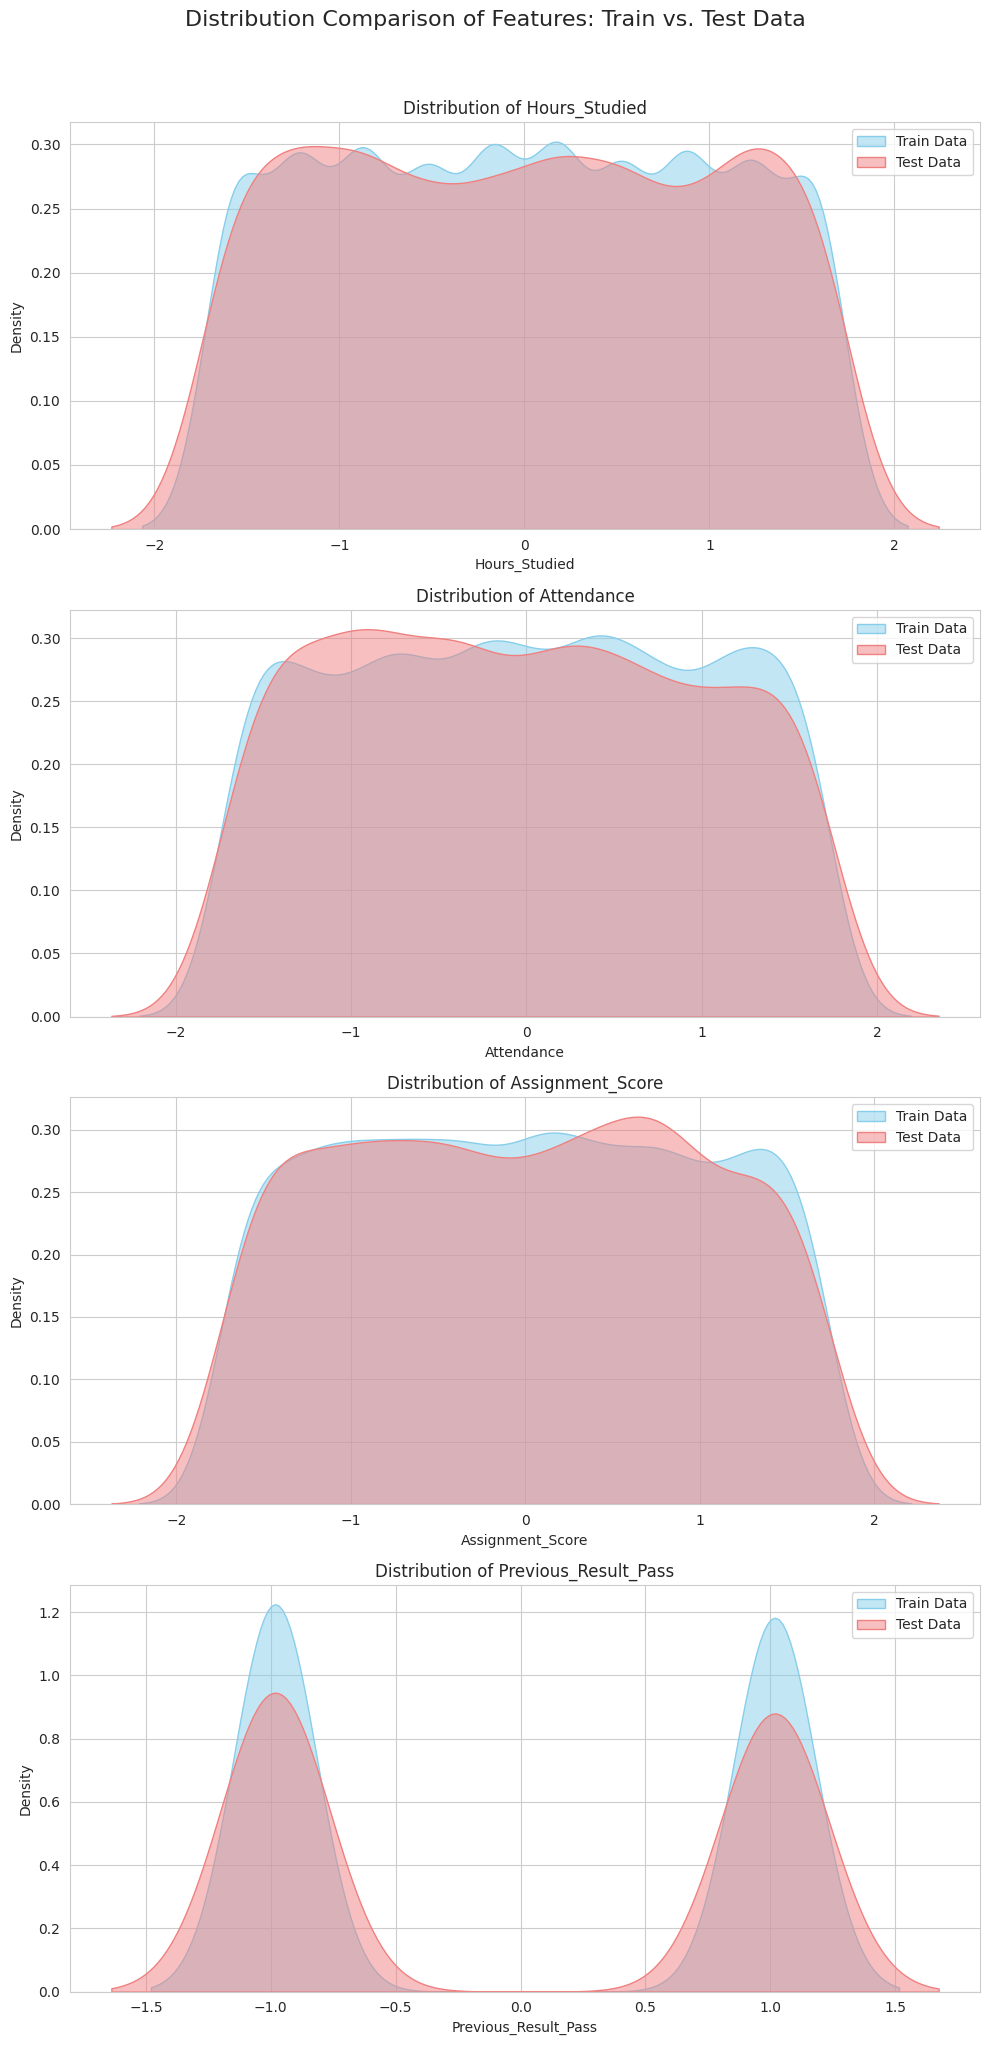

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

feature_names = xtrain.columns
num_features = len(feature_names)

# Create a figure with subplots for each feature
fig, axes = plt.subplots(num_features, 1, figsize=(10, 5 * num_features))
fig.suptitle('Distribution Comparison of Features: Train vs. Test Data', y=1.02, fontsize=16)

# Ensure axes is always an array for consistent indexing
if num_features == 1:
    axes = [axes]

for i, feature in enumerate(feature_names):
    sns.kdeplot(xtrain[feature], ax=axes[i], color='skyblue', label='Train Data', fill=True, alpha=0.5)
    sns.kdeplot(xtest[feature], ax=axes[i], color='lightcoral', label='Test Data', fill=True, alpha=0.5)
    axes[i].set_title(f'Distribution of {feature}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Density')
    axes[i].legend()

plt.tight_layout()
plt.show()

/tmp/ipykernel_1759/1813501029.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=ytrain, ax=axes[0], palette='viridis')
/tmp/ipykernel_1759/1813501029.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=ytest, ax=axes[1], palette='viridis')


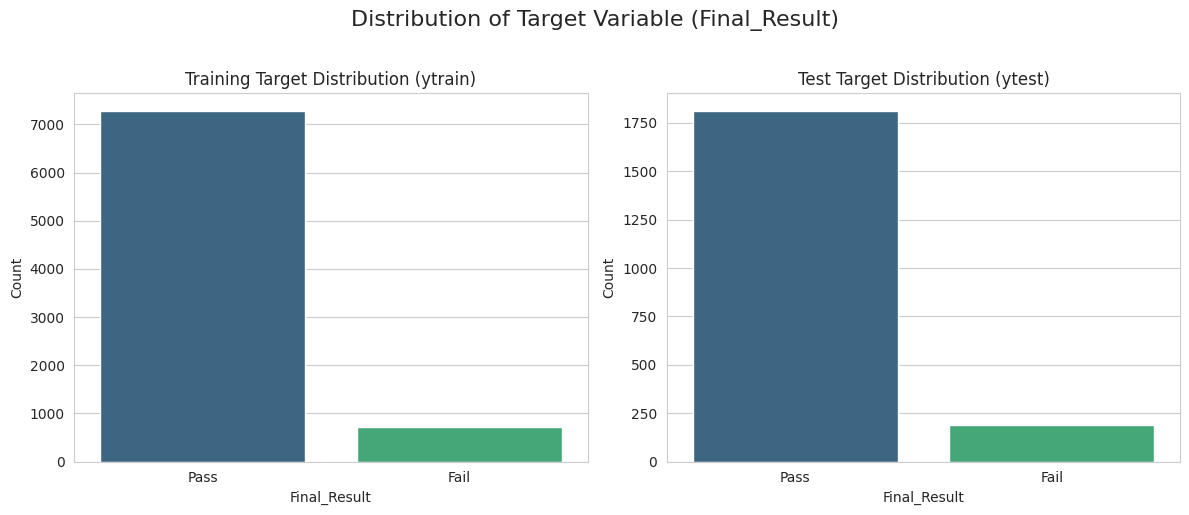

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Plot distribution of the target variable (ytrain and ytest)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Distribution of Target Variable (Final_Result)', y=1.02, fontsize=16)

sns.countplot(x=ytrain, ax=axes[0], palette='viridis')
axes[0].set_title('Training Target Distribution (ytrain)')
axes[0].set_xlabel('Final_Result')
axes[0].set_ylabel('Count')

sns.countplot(x=ytest, ax=axes[1], palette='viridis')
axes[1].set_title('Test Target Distribution (ytest)')
axes[1].set_xlabel('Final_Result')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()